# PFlogPF PCA for Angelidis lung pseudobulk RNA-seq

This notebook mirrors the `scclrR` Seurat vignette in Python. It uses the included Angelidis lung pseudobulk count matrix, runs sparse PFlogPF normalization and PCA with `scclr`, and compares PC1 loadings to an old-vs-young differential expression estimate from `edgepython`.

The data files in `examples/data/` are genes by mouse-level pseudobulk samples. `scclr` expects observations by variables, so the notebook transposes the matrix when constructing the `AnnData` object.

In [1]:
from pathlib import Path
import warnings

import anndata as ad
import edgepython as edge
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scclr
from scipy.io import mmread
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 140, "font.size": 10})

## Read the included pseudobulk data

The count matrix is genes by samples, matching edgeR/edgepython convention. The `AnnData` object below stores samples as observations and genes as variables.

In [2]:
DATA = Path("data")
if not (DATA / "angelidis_lung_pseudobulk_counts.mtx.gz").exists():
    DATA = Path("examples/data")

counts = mmread(DATA / "angelidis_lung_pseudobulk_counts.mtx.gz").tocsr().astype(float)
samples = pd.read_csv(DATA / "angelidis_lung_pseudobulk_samples.csv")
genes = pd.read_csv(DATA / "angelidis_lung_pseudobulk_genes.csv")

def make_unique(values):
    seen = {}
    out = []
    for value in map(str, values):
        n = seen.get(value, 0)
        seen[value] = n + 1
        out.append(value if n == 0 else f"{value}.{n}")
    return out

gene_names = make_unique(genes["gene"])
sample_names = samples["sample"].astype(str).tolist()

counts.shape, samples["age_label"].value_counts().to_dict()

((21969, 15), {'Young': 8, 'Old': 7})

In [3]:
adata = ad.AnnData(
    X=counts.T.tocsr(),
    obs=samples.copy().set_index("sample", drop=False),
    var=pd.DataFrame(index=gene_names),
)
adata

AnnData object with n_obs × n_vars = 15 × 21969
    obs: 'sample', 'age', 'age_label', 'n_cells', 'total_umi', 'sample_id'

## PFlogPF normalization and sparse PCA

`target="auto"` estimates the overdispersion parameter and sets the shifted-log scale `K = 4 * alpha * mean_depth`. The normalized matrix is stored sparsely as `adata.layers["pflogpf"]`, with the centering vector in `adata.obs["pflogpf_center"]`.

In [4]:
scclr.pp.pflogpf(adata, target="auto")
scclr.tl.pca(adata, n_comps=5, ncv=12)

adata.uns["pflogpf"], adata.uns["pca"]["variance_ratio"][:2]

({'k': 1300173.1729824126,
  'alpha': 0.40186872492902276,
  'target': 'auto',
  'center': True,
  'log1p': True},
 array([0.18390822, 0.12460584]))

## PCA panel

The sample-level PFlogPF PCA separates young and old pseudobulk samples along PC1.

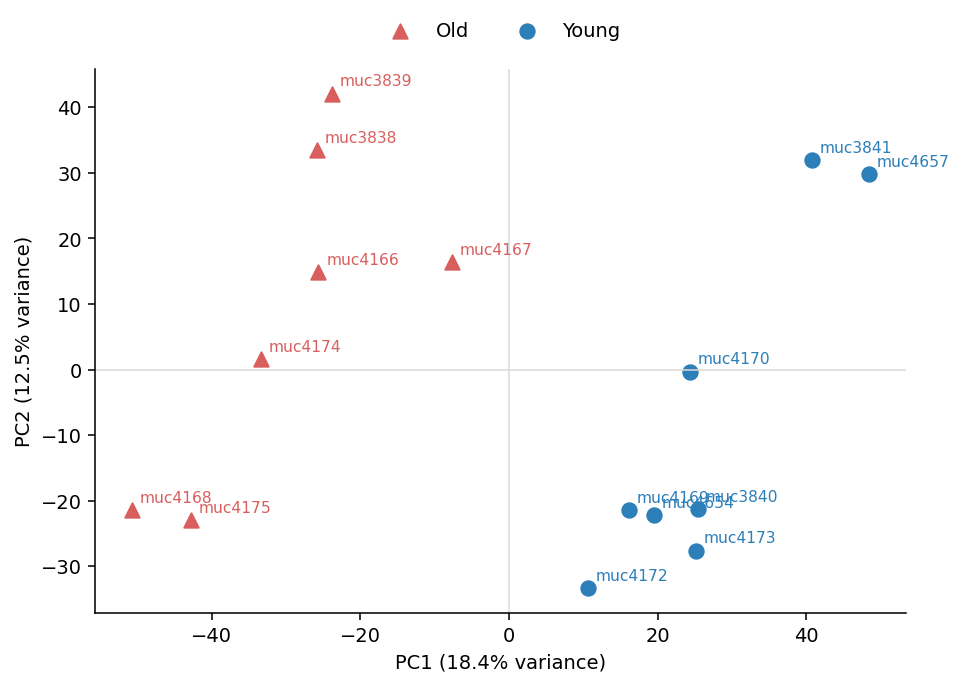

In [5]:
pca_df = pd.DataFrame(
    adata.obsm["X_pca"][:, :2],
    columns=["PC1", "PC2"],
    index=adata.obs_names,
).join(adata.obs[["sample", "age_label", "age", "n_cells"]])
var = adata.uns["pca"]["variance_ratio"]

colors = {"Young": "#2c7fb8", "Old": "#d95f5f"}
markers = {"Young": "o", "Old": "^"}

fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(0, color="0.85", lw=0.8)
ax.axvline(0, color="0.85", lw=0.8)
for label, group in pca_df.groupby("age_label"):
    ax.scatter(group["PC1"], group["PC2"], s=55, c=colors[label], marker=markers[label], label=label)
    for _, row in group.iterrows():
        ax.annotate(row["sample"], (row["PC1"], row["PC2"]), xytext=(4, 4), textcoords="offset points", color=colors[label], fontsize=8)
ax.set_xlabel(f"PC1 ({100 * var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({100 * var[1]:.1f}% variance)")
ax.legend(frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.12))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## edgepython old-vs-young comparison

`edgepython` provides an edgeR-like Python API. Here we use the same structure as the R vignette: create a `DGEList`, filter low-expression genes, calculate TMM normalization factors, estimate dispersion, fit a quasi-likelihood GLM, and test the old-vs-young coefficient.

In [6]:
sample_meta = samples.copy()
sample_meta["group"] = pd.Categorical(sample_meta["age_label"], categories=["Young", "Old"])
counts_dense = counts.toarray()

y0 = edge.make_dgelist(
    counts_dense,
    samples=sample_meta,
    group=sample_meta["group"],
    genes=pd.DataFrame({"gene": gene_names}),
)
keep = edge.filter_by_expr(y0, group=sample_meta["group"])

# edgepython 0.2.x has a row-subsetting quirk for DGEList objects, so construct
# the filtered DGEList directly from the filtered count matrix.
y = edge.make_dgelist(
    counts_dense[keep, :],
    samples=sample_meta,
    group=sample_meta["group"],
    genes=pd.DataFrame({"gene": np.array(gene_names)[keep]}),
)
y = edge.calc_norm_factors(y)
design = edge.model_matrix("~ group", y.samples)
y = edge.estimate_disp(y, design=design)
fit = edge.glm_ql_fit(y, design=design)
qlf = edge.glm_ql_ftest(fit, coef=1)
de = edge.top_tags(qlf, n=np.inf)["table"].copy()

de.head(), de.shape

(        gene     logFC     logCPM        PValue           F           FDR
 8526  mt-Nd3  6.657275   5.437556  8.546613e-15  198.757313  7.294534e-11
 3590    Ighm  4.902690  11.056085  2.231608e-09  110.262030  8.837163e-06
 5258    Perp -1.693261   5.469792  3.106208e-09  106.193213  8.837163e-06
 1885   Cxcr6  2.585818   4.446355  9.532724e-09   92.050669  2.034045e-05
 4629    Muc1 -1.257268   7.807238  1.716575e-08   85.600642  2.930194e-05,
 (8535, 6))

## PC1 loadings vs. supervised log fold change

PCA component signs are arbitrary. For visualization, each loading vector is oriented so its correlation with the old-vs-young `edgepython` log fold change is positive.

In [7]:
pflogpf_loadings = pd.DataFrame({
    "gene": adata.var_names,
    "pc1_loading": adata.varm["PCs"][:, 0],
})
merged = pflogpf_loadings.merge(de, on="gene")
if merged["pc1_loading"].corr(merged["logFC"]) < 0:
    merged["pc1_loading"] *= -1
merged["pc1_loading"].corr(merged["logFC"])

np.float64(0.9380857211918131)

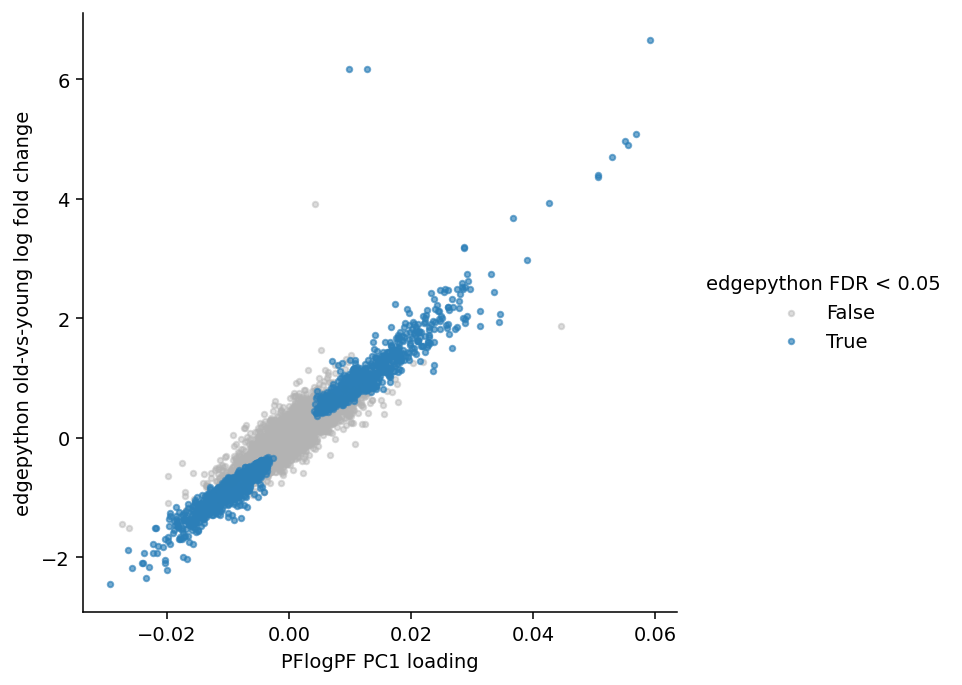

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
mask = merged["FDR"] < 0.05
ax.scatter(merged.loc[~mask, "pc1_loading"], merged.loc[~mask, "logFC"], s=8, alpha=0.45, color="0.70", label="False")
ax.scatter(merged.loc[mask, "pc1_loading"], merged.loc[mask, "logFC"], s=8, alpha=0.65, color="#2c7fb8", label="True")
ax.set_xlabel("PFlogPF PC1 loading")
ax.set_ylabel("edgepython old-vs-young log fold change")
ax.legend(title="edgepython FDR < 0.05", frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## Seurat-default-style normalization comparison in Python

For a Python analogue of the Seurat default workflow, normalize each sample to 10,000 counts, apply `log1p`, select the 2,000 most variable genes, center/scale those genes, and run ordinary PCA. This gives a comparison loading plot using the same `edgepython` differential expression table.

In [9]:
lib_size = np.asarray(counts.sum(axis=0)).ravel()
lognorm = counts.multiply(10000 / lib_size).log1p().T.toarray()  # samples x genes

feature_var = lognorm.var(axis=0, ddof=1)
variable_idx = np.argsort(feature_var)[-min(2000, lognorm.shape[1]):]
scaled = StandardScaler(with_mean=True, with_std=True).fit_transform(lognorm[:, variable_idx])
seurat_like = PCA(n_components=5, svd_solver="full", random_state=0).fit(scaled)

seurat_loadings = pd.DataFrame({
    "gene": np.array(gene_names)[variable_idx],
    "pc1_loading": seurat_like.components_[0],
})
merged_seurat = seurat_loadings.merge(de, on="gene")
if merged_seurat["pc1_loading"].corr(merged_seurat["logFC"]) < 0:
    merged_seurat["pc1_loading"] *= -1
merged_seurat["pc1_loading"].corr(merged_seurat["logFC"]), merged_seurat.shape

(np.float64(0.7614161980064904), (1903, 7))

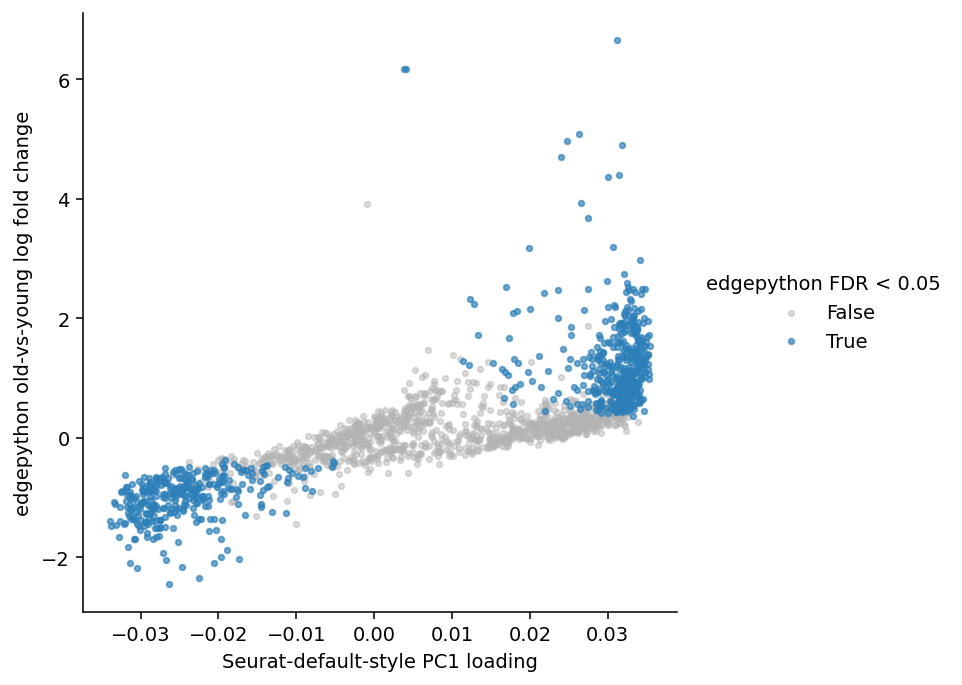

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
mask = merged_seurat["FDR"] < 0.05
ax.scatter(merged_seurat.loc[~mask, "pc1_loading"], merged_seurat.loc[~mask, "logFC"], s=8, alpha=0.45, color="0.70", label="False")
ax.scatter(merged_seurat.loc[mask, "pc1_loading"], merged_seurat.loc[mask, "logFC"], s=8, alpha=0.65, color="#2c7fb8", label="True")
ax.set_xlabel("Seurat-default-style PC1 loading")
ax.set_ylabel("edgepython old-vs-young log fold change")
ax.legend(title="edgepython FDR < 0.05", frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()